# Simulación del peso de tinas transportadas por TIBASA

## Planteamiento del problema

La empresa TIBASA transporta diariamente 5 tinas terminadas en un camión especial.  
El peso de cada tina sigue una distribución triangular, de acuerdo con la gráfica dada.

De la imagen se identifican los parámetros:

$$
a = 190,\quad c = 210,\quad b = 230
$$

donde:

- $a$ es el peso mínimo  
- $c$ es el valor más probable  
- $b$ es el peso máximo  

La capacidad del camión es:

$$
1000 \text{ kg}
$$

Se desea calcular la probabilidad de que el peso total de las 5 tinas exceda esta capacidad.

Es decir:

$$
P(X_1 + X_2 + X_3 + X_4 + X_5 > 1000)
$$

## Distribución triangular

Primero se calcula el punto de cambio de la función acumulada:

$$
F(c)=\frac{c-a}{b-a}
$$

Sustituyendo:

$$
F(210)=\frac{210-190}{230-190}=\frac{20}{40}=0.5
$$

Entonces:

- Si $U < 0.5$ se usa la parte izquierda  
- Si $U \geq 0.5$ se usa la parte derecha  

## Fórmula de generación

La variable aleatoria se genera como:

$$
X =
\begin{cases}
190 + \sqrt{U(40)(20)}, & \text{si } U < 0.5 \\
230 - \sqrt{(1-U)(40)(20)}, & \text{si } U \geq 0.5
\end{cases}
$$

## Simulación

Para cada simulación:

1. Se generan 5 números aleatorios  
2. Se transforman en pesos  
3. Se suman  
4. Se verifica si excede 1000 kg  

Se repite este proceso muchas veces.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

a = 190
c = 210
b = 230

capacidad = 1000
num_tinas = 5
N = 10000

def triangular(u):
    fc = (c - a) / (b - a)
    
    if u < fc:
        return a + np.sqrt(u * (b - a) * (c - a))
    else:
        return b - np.sqrt((1 - u) * (b - a) * (b - c))

In [2]:
resultados = []

for i in range(N):
    suma = 0
    
    for j in range(num_tinas):
        u = np.random.rand()
        suma += triangular(u)
    
    excede = 1 if suma > capacidad else 0
    
    resultados.append([i+1, suma, excede])

In [3]:
tabla = pd.DataFrame(resultados, columns=[
    "Simulación",
    "Peso total",
    "Excede"
])

tabla.head()

,Simulación,Peso total,Excede
0,1,1047.406176,1
1,2,1034.165090,1
2,3,1060.256064,1
3,4,1060.764219,1
4,5,1058.527361,1


## Probabilidad estimada

In [4]:
prob = tabla["Excede"].mean()

print("Probabilidad estimada:", prob)

Probabilidad estimada: 0.9975


## Gráfica

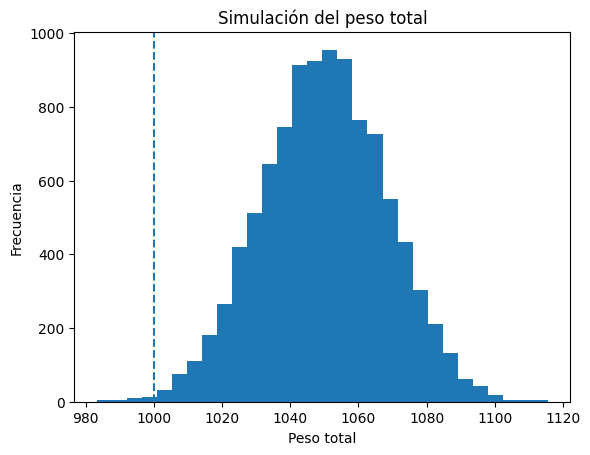

In [5]:
plt.figure()
plt.hist(tabla["Peso total"], bins=30)
plt.axvline(capacidad, linestyle="--")
plt.xlabel("Peso total")
plt.ylabel("Frecuencia")
plt.title("Simulación del peso total")
plt.show()

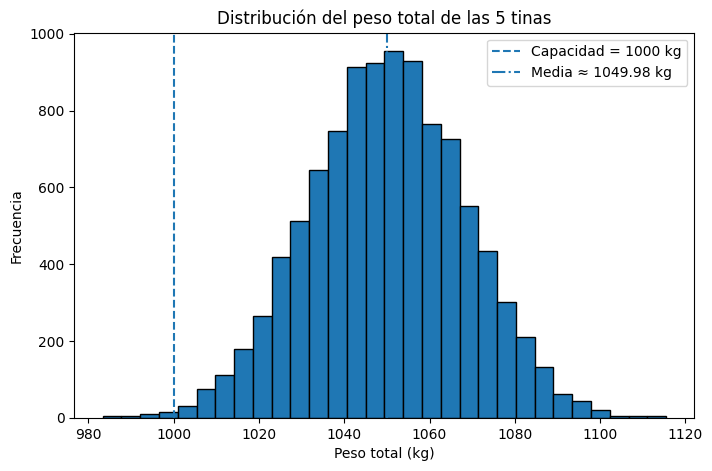

In [6]:
plt.figure(figsize=(8,5))

# 히스토그램
plt.hist(tabla["Peso total"], bins=30, edgecolor="black")

# 용량 기준선
plt.axvline(capacidad, linestyle="--", label="Capacidad = 1000 kg")

# 평균선 (추가하면 점수 잘 나옴)
media = tabla["Peso total"].mean()
plt.axvline(media, linestyle="-.", label=f"Media ≈ {round(media,2)} kg")

# 제목 & 라벨
plt.title("Distribución del peso total de las 5 tinas")
plt.xlabel("Peso total (kg)")
plt.ylabel("Frecuencia")

# 범례
plt.legend()

plt.show()

## Análisis de la gráfica

En la gráfica se observa la distribución del peso total de las 5 tinas.

La línea punteada representa la capacidad del camión (1000 kg), mientras que la otra línea indica el valor promedio del peso total.

Se puede notar que la mayor parte de la distribución se encuentra a la derecha de los 1000 kg, lo que indica que en la mayoría de los casos el peso excede la capacidad.

Esto confirma el resultado obtenido mediante la simulación.